# EDA de `anuncios` — hacia un modelo de precio

Este notebook trabaja sobre la **salida limpia del pipeline** (`data/processed/anuncios.parquet`),
no sobre `data/raw/`. La diferencia importa: `notebooks/eda_raw_data.ipynb` fue un EDA de **calidad de
datos**, hecho para *definir* las 12 reglas de negocio del transform. Este es un EDA de **modelado**,
hecho para responder si la data alcanza para predecir precio.

Tres preguntas, en este orden:

1. ¿Cómo está distribuida la información por ciudad y sector?
2. ¿Qué correlaciona con el precio, y cuánta información nueva aporta cada variable?
3. ¿Alcanzan las features actuales, o hay que enriquecer con datos externos?

El notebook tiene dos partes:

| Parte | Qué hace | Red |
|---|---|---|
| **A** (§1–§7) | EDA y baseline sobre la data limpia | No — reproducible offline |
| **B** (§8–§13) | Prototipo de enriquecimiento geoespacial (OSM) | Sí — con caché en `data/external/` |

> Se lee el **parquet**, no el CSV. El CSV degrada los dtypes a texto (los `Int8` con nulos, los
> `bool`) y obliga a re-castear todo a mano.

In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

RAIZ = pathlib.Path("..").resolve()
PROCESADO = RAIZ / "data" / "processed"
EXTERNO = RAIZ / "data" / "external"

PERCENTILES = [.01, .05, .25, .5, .75, .95, .99]
NUMERICAS = ["area_m2", "habitaciones", "banos", "parqueaderos"]
# El precio vive en dos columnas excluyentes porque son escalas distintas:
# canon mensual vs. precio de venta. Nunca se mezclan en una sola serie.
OPERACIONES = {"arriendo": "precio_arriendo", "venta": "precio_venta"}

df = pd.read_parquet(PROCESADO / "anuncios.parquet")
resumen_transform = json.loads((PROCESADO / "transform_resumen.json").read_text(encoding="utf-8"))


def resumen_nulos(datos):
    return pd.DataFrame({
        "dtype": datos.dtypes.astype(str),
        "nulos": datos.isna().sum(),
        "nulos_%": (datos.isna().mean() * 100).round(2),
        "unicos": datos.nunique(),
    })


def marco_operacion(operacion):
    """Devuelve el subconjunto de una operación con el precio ya unificado en `precio`."""
    columna = OPERACIONES[operacion]
    sub = df[df[columna].notna()].copy()
    sub["precio"] = sub[columna].astype("float64")
    sub["log_precio"] = np.log(sub["precio"])
    sub["log_area"] = np.log(sub["area_m2"].astype("float64"))
    sub["log_precio_m2"] = np.log(sub["precio_m2"].astype("float64"))
    return sub


MARCOS = {nombre: marco_operacion(nombre) for nombre in OPERACIONES}

print(f"filas: {len(df):,} | columnas: {df.shape[1]}")
print({nombre: len(marco) for nombre, marco in MARCOS.items()})

filas: 44,833 | columnas: 39
{'arriendo': 22059, 'venta': 22774}


## 1. Qué sobrevivió al transform (y qué sesgo introdujo)

Antes de mirar una sola correlación hay que saber **sobre qué población** estamos hablando. El
transform no es neutral: descartó el 11,68 % de las filas, y ese descarte **no es aleatorio**.

Lo que hay que tener presente al leer todo lo que sigue:

- Se fueron **2.086 inmuebles no residenciales** (oficinas, bodegas, lotes). El modelo que salga de
  acá aplica a **vivienda urbana**, no a inmueble en general.
- Se fueron **1.776 filas por área fuera de rango** y otras 1.776 **sin área**. Como el área es el
  predictor más fuerte, filtrar por área recorta justo la cola donde el modelo sería más incierto.
- Los `outlier_*` (2.354 filas) se cortaron por IQR en escala log. Eso **comprime la cola de precios
  altos**: el modelo va a subestimar el segmento de lujo, porque casi no lo vio.

Nada de esto está mal — es la compuerta de calidad haciendo su trabajo. Pero es un **sesgo de
selección** y hay que declararlo, no descubrirlo cuando el modelo falle en producción.

In [2]:
print(f"procesado: {resumen_transform['total_procesado']:,}"
      f" | limpio: {resumen_transform['limpio']:,}"
      f" | cuarentena: {resumen_transform['cuarentena']:,}"
      f" | rechazo: {resumen_transform['tasa_rechazo_%']} %")

motivos = pd.Series(resumen_transform["motivos_rechazo"]).sort_values(ascending=False)
display(motivos.to_frame("filas").assign(**{"%_del_total": (motivos / resumen_transform["total_procesado"] * 100).round(2)}))

# Coherencia: el JSON del transform tiene que cuadrar con lo que realmente cargamos.
por_operacion = df["operacion"].value_counts().to_dict()
print("\noperacion en el parquet:", por_operacion)
print("operacion segun el resumen:", resumen_transform["limpio_por_operacion"])
assert por_operacion == resumen_transform["limpio_por_operacion"], "el parquet no cuadra con transform_resumen.json"
print("-> cuadra")

procesado: 50,761 | limpio: 44,833 | cuarentena: 5,928 | rechazo: 11.68 %


,filas,%_del_total
tipo_no_residencial,2086,4.11
area_fuera_de_rango,1776,3.50
sin_area,1776,3.50
area_posible_lote,875,1.72
outlier_area_m2,826,1.63
outlier_precio_m2,785,1.55
outlier_precio_arriendo,504,0.99
outlier_precio_venta,239,0.47
sin_precio,169,0.33
precio_venta_fuera_de_rango,66,0.13



operacion en el parquet: {'venta': 22536, 'arriendo': 22059, 'ambas': 238}
operacion segun el resumen: {'venta': 22536, 'arriendo': 22059, 'ambas': 238}
-> cuadra


In [3]:
display(resumen_nulos(df).sort_values("nulos_%", ascending=False).head(12))

# Las columnas de banderas ya cumplieron su función en el transform: en la data limpia
# son constantes en False. Sirven para auditar, no como features.
banderas = [c for c in df.columns if df[c].dtype == bool]
constantes = [c for c in banderas if df[c].nunique() == 1]
print(f"banderas booleanas: {len(banderas)} | constantes (todas False): {len(constantes)}")
print("informativas:", [c for c in banderas if c not in constantes])

,dtype,nulos,nulos_%,unicos
precio_arriendo,Int64,22774,50.80,1343
precio_venta,Int64,22059,49.20,1911
parqueaderos,Int8,9062,20.21,4
sector,string,425,0.95,7082
sector_clave,str,425,0.95,7001
habitaciones,Int8,54,0.12,5
banos,Int8,34,0.08,5
precio_texto,str,0,0.00,3254
operacion_feed,str,0,0.00,2
tipo_feed,str,0,0.00,3


banderas booleanas: 17 | constantes (todas False): 13
informativas: ['es_dual', 'habitaciones_es_tope', 'banos_es_tope', 'parqueaderos_es_tope']


## 2. Distribución geográfica: acá está el problema

Esta sección es la más importante del notebook y conviene leerla despacio, porque define qué se
puede y qué no se puede hacer con esta data.

**La cobertura por ciudad está muy concentrada**: las 10 ciudades más grandes son el 78 % de los
anuncios, y solo Bogotá + Medellín son casi la mitad. Las 231 ciudades no son 231 mercados
utilizables — hay una cola larguísima de municipios con un puñado de anuncios.

**El sector es la variable con más señal y a la vez la más inservible.** Hay ~7.000 sectores únicos
para 44.833 filas. Bogotá sola declara **2.535 sectores** para 13.674 anuncios: unas 5 filas por
sector en promedio. Eso no es una categoría, es casi un identificador.

Y no es un problema de limpieza. El sector viene del título del anuncio, escrito por el anunciante:
`chico`, `chico norte`, `chico navarra`, `chico reservado` y `el chico` conviven como valores
distintos siendo la misma zona. Ninguna normalización de strings arregla eso de raíz.

In [4]:
conteo_ciudad = df["ciudad_clave"].value_counts()
print(f"ciudades: {df['ciudad_clave'].nunique()} | sectores: {df['sector_clave'].nunique()}")
print(f"top-10 ciudades = {conteo_ciudad.head(10).sum() / len(df) * 100:.1f} % de los anuncios")
print(f"filas en ciudades con menos de 30 anuncios: {int(conteo_ciudad[conteo_ciudad < 30].sum()):,}")
display(conteo_ciudad.head(12).to_frame("anuncios").assign(**{"%": (conteo_ciudad.head(12) / len(df) * 100).round(1)}))

filas = []
for ciudad in conteo_ciudad.head(8).index:
    sub = df[df["ciudad_clave"] == ciudad]
    sectores = sub["sector_clave"].value_counts()
    filas.append({
        "ciudad": ciudad,
        "anuncios": len(sub),
        "sectores": sub["sector_clave"].nunique(),
        "anuncios_x_sector": round(len(sub) / max(sub["sector_clave"].nunique(), 1), 1),
        "sectores_n>=30": int((sectores >= 30).sum()),
        "%_filas_en_sectores_n>=30": round(sectores[sectores >= 30].sum() / len(sub) * 100, 1),
    })
display(pd.DataFrame(filas))

ciudades: 231 | sectores: 7001
top-10 ciudades = 78.4 % de los anuncios
filas en ciudades con menos de 30 anuncios: 999


,anuncios,%
ciudad_clave,,
bogota d.c.,13674,30.5
medellin,8239,18.4
envigado,3011,6.7
barranquilla,2483,5.5
cali,2209,4.9
pereira,1410,3.1
chia,1356,3.0
rionegro,1113,2.5
cartagena de indias,865,1.9


,ciudad,anuncios,sectores,anuncios_x_sector,sectores_n>=30,%_filas_en_sectores_n>=30
0,bogota d.c.,13674,2535,5.4,77,49.8
1,medellin,8239,612,13.5,44,75.7
2,envigado,3011,248,12.1,19,65.7
3,barranquilla,2483,199,12.5,25,72.5
4,cali,2209,398,5.6,12,42.6
5,pereira,1410,131,10.8,10,67.7
6,chia,1356,308,4.4,5,37.1
7,rionegro,1113,160,7.0,9,64.9


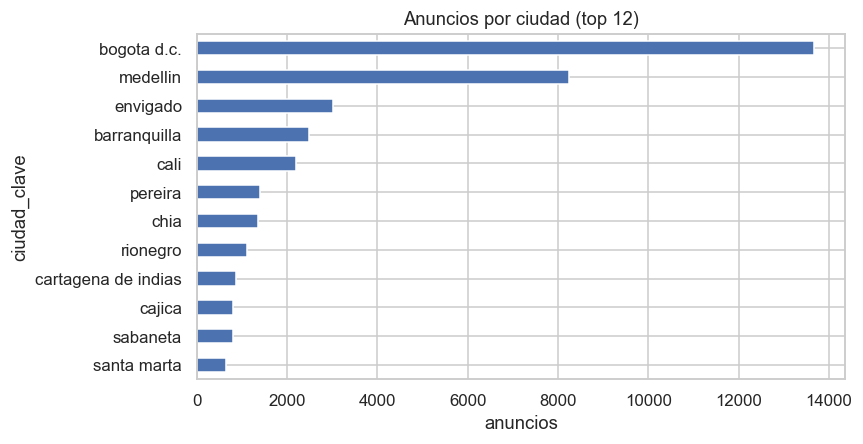

grupos ciudad|sector: 8,204
  con n == 1 : 4,993 sectores (60.9 % de los grupos)
  con n >= 30: 252 sectores, que cubren 51.8 % de las filas


In [27]:
# Mantenemos el cálculo de 'tam_sector' porque lo usas en los prints de abajo
tam_sector = (df["ciudad_clave"].astype(str) + "|" + df["sector_clave"].astype(str)).value_counts()

# Creamos un solo gráfico (1 fila, 1 columna) con un tamaño adecuado
fig, ax = plt.subplots(figsize=(8, 4.2))

# Graficamos el top 12 de ciudades usando el eje único 'ax'
conteo_ciudad.head(12).sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Anuncios por ciudad (top 12)")
ax.set_xlabel("anuncios")

plt.tight_layout()
plt.show()

# Los prints se mantienen idénticos
print(f"grupos ciudad|sector: {len(tam_sector):,}")
print(f"  con n == 1 : {int((tam_sector == 1).sum()):,} sectores ({(tam_sector == 1).sum() / len(tam_sector) * 100:.1f} % de los grupos)")
print(f"  con n >= 30: {int((tam_sector >= 30).sum()):,} sectores, que cubren {tam_sector[tam_sector >= 30].sum() / len(df) * 100:.1f} % de las filas")


## 3. El target: dos variables, dos escalas, y por qué va en log

`precio_arriendo` y `precio_venta` son **excluyentes y no comparables**: un canon mensual y un precio
de venta no viven en la misma unidad. Mezclarlas en una sola columna `precio` con una bandera de
operación produciría un target bimodal separado por tres órdenes de magnitud. **Un modelo por
operación.**

Las dos distribuciones tienen la firma clásica del precio inmobiliario: asimetría fuerte a la
derecha, media muy por encima de la mediana. En arriendo, media 6,76 M vs. mediana 4,60 M.

En log, las dos se vuelven **casi simétricas**. Eso no es cosmética, tiene tres consecuencias
concretas para el modelo:

1. El error se vuelve **multiplicativo**: equivocarse por 50 M en una propiedad de 200 M y en una de
   3.000 M no es el mismo error, y en log el modelo lo entiende así.
2. La relación precio–área pasa a ser **lineal** (§4): en log–log, el coeficiente del área es
   directamente la elasticidad.
3. Los residuos se acercan a homocedásticos, que es lo que casi todo regresor asume.

**Target: `log(precio)`.** Y `precio_m2` como métrica de comparación entre zonas, porque neutraliza
el tamaño y deja ver la ubicación.

In [6]:
for nombre, marco in MARCOS.items():
    print(f"=== {nombre.upper()}  n = {len(marco):,} ===")
    display(marco[["precio", "area_m2", "precio_m2"]].astype("float64")
            .describe(percentiles=PERCENTILES)
            .apply(lambda col: col.map("{:,.0f}".format)))
    asimetria = marco["precio"].skew()
    print(f"asimetría en nivel: {asimetria:.2f} | en log: {marco['log_precio'].skew():.2f}"
          f" | media/mediana: {marco['precio'].mean() / marco['precio'].median():.2f}\n")

=== ARRIENDO  n = 22,059 ===


,precio,area_m2,precio_m2
count,"22,059","22,059","22,059"
mean,"6,764,309",180,"44,364"
std,"6,195,960",181,"19,889"
min,"600,000",20,"10,556"
1%,"950,000",23,"13,280"
5%,"1,380,000",30,"18,518"
25%,"2,700,000",61,"29,825"
50%,"4,600,000",110,"41,429"
75%,"8,700,000",241,"54,945"
95%,"18,700,000",525,"82,000"


asimetría en nivel: 2.36 | en log: 0.15 | media/mediana: 1.47

=== VENTA  n = 22,774 ===


,precio,area_m2,precio_m2
count,"22,774","22,774","22,774"
mean,"1,196,255,318",202,"6,744,499"
std,"1,187,320,359",205,"3,089,972"
min,"100,000,000",20,"1,562,500"
1%,"168,000,000",24,"1,914,619"
5%,"229,900,000",32,"2,664,169"
25%,"419,000,000",65,"4,494,382"
50%,"760,000,000",133,"6,240,817"
75%,"1,550,000,000",270,"8,429,025"
95%,"3,550,000,000",588,"12,609,422"


asimetría en nivel: 2.44 | en log: 0.25 | media/mediana: 1.57



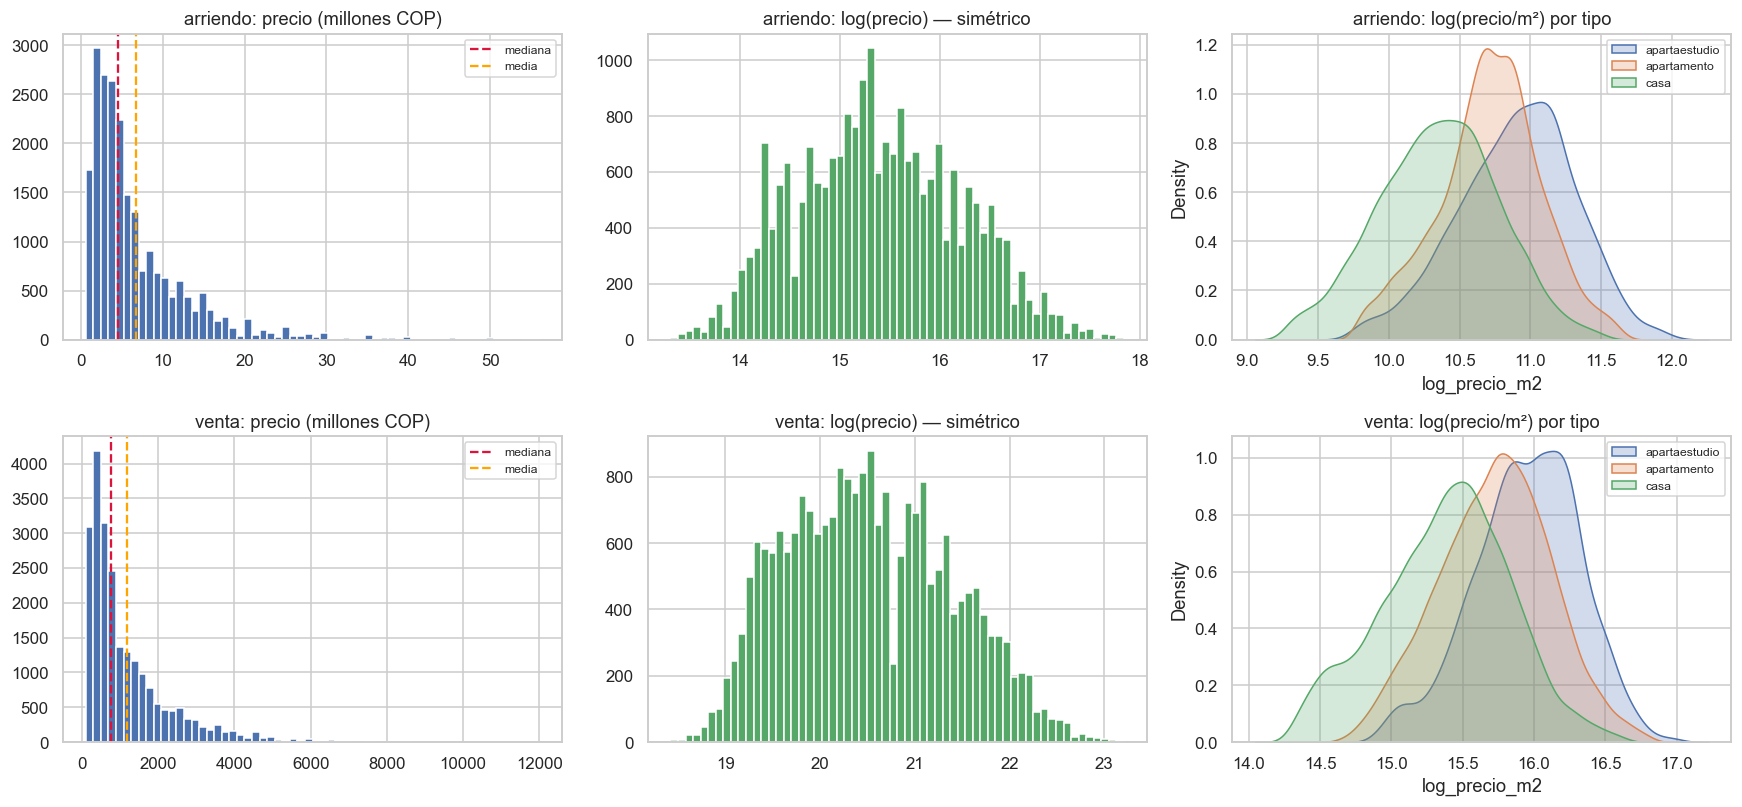

In [7]:
fig, ejes = plt.subplots(2, 3, figsize=(16, 7.5))
for fila, (nombre, marco) in enumerate(MARCOS.items()):
    ejes[fila, 0].hist(marco["precio"] / 1e6, bins=60, color="#4C72B0")
    ejes[fila, 0].set_title(f"{nombre}: precio (millones COP)")
    ejes[fila, 0].axvline(marco["precio"].median() / 1e6, color="crimson", ls="--", label="mediana")
    ejes[fila, 0].axvline(marco["precio"].mean() / 1e6, color="orange", ls="--", label="media")
    ejes[fila, 0].legend(fontsize=8)

    ejes[fila, 1].hist(marco["log_precio"], bins=60, color="#55A868")
    ejes[fila, 1].set_title(f"{nombre}: log(precio) — simétrico")

    for tipo, grupo in marco.groupby("tipo_inmueble"):
        sns.kdeplot(grupo["log_precio_m2"], ax=ejes[fila, 2], label=tipo, fill=True, alpha=.25)
    ejes[fila, 2].set_title(f"{nombre}: log(precio/m²) por tipo")
    ejes[fila, 2].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Correlaciones: el área manda, y el resto la repite

Acá aparece el hallazgo incómodo. Sí, todas las variables correlacionan con el precio. El problema
es que **también correlacionan entre sí**.

Números de arriendo (Spearman, que es el que vale con distribuciones asimétricas):

| par | ρ |
|---|---|
| precio – área | **0,875** |
| precio – baños | 0,782 |
| precio – parqueaderos | 0,720 |
| precio – habitaciones | 0,637 |
| **área – baños** | **0,843** |
| **área – habitaciones** | **0,821** |

Leelo así: `banos` correlaciona con el precio (0,78)… pero correlaciona casi igual de fuerte con el
área (0,84). **No es una variable independiente, es un proxy del tamaño.** Lo mismo habitaciones.
Una casa grande tiene más baños *porque* es grande.

Traducción práctica: **no tenés 5 features, tenés ~1,5.** El área, y un poco de información residual
en los conteos. Por eso agregar ubicación real no es un lujo — es la única fuente de señal nueva
disponible.

El log–log precio–área da Pearson **0,862** en las dos operaciones. Esa es la relación estructural:
el precio escala con el área elevada a una potencia. La pendiente es **menor que 1** (§5), o sea que
el m² se abarata a medida que la propiedad crece.

=== ARRIENDO ===


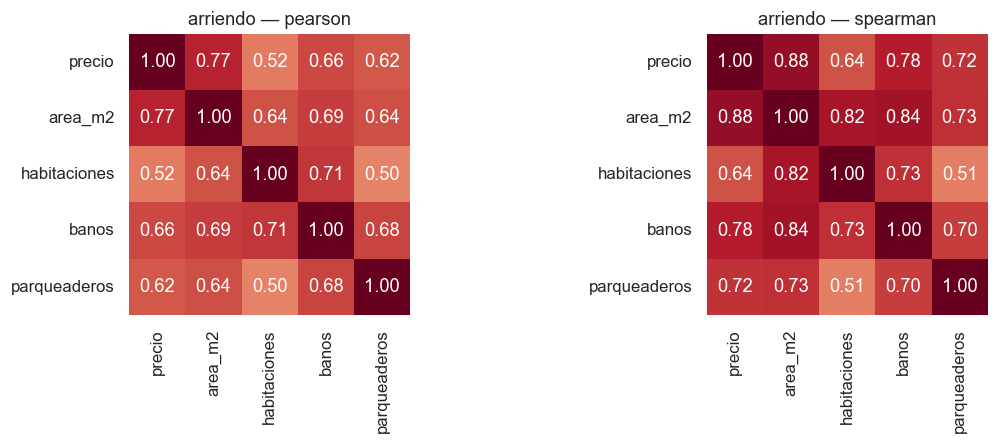

  habitaciones  corr con log(precio): +0.637 | corr con el RESIDUO tras quitar el área: -0.139
  banos         corr con log(precio): +0.782 | corr con el RESIDUO tras quitar el área: +0.097
  parqueaderos  corr con log(precio): +0.720 | corr con el RESIDUO tras quitar el área: +0.130

=== VENTA ===


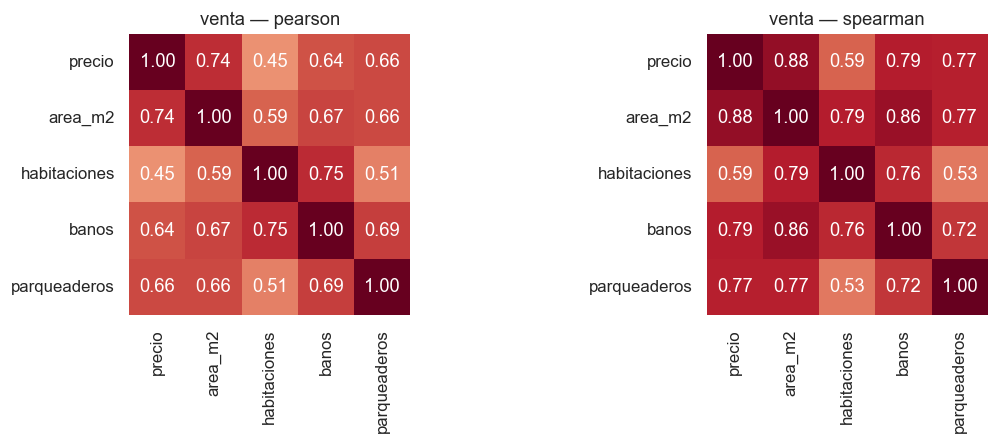

  habitaciones  corr con log(precio): +0.589 | corr con el RESIDUO tras quitar el área: -0.187
  banos         corr con log(precio): +0.789 | corr con el RESIDUO tras quitar el área: +0.075
  parqueaderos  corr con log(precio): +0.775 | corr con el RESIDUO tras quitar el área: +0.210



In [8]:
for nombre, marco in MARCOS.items():
    columnas = ["precio"] + NUMERICAS
    num = marco[columnas].astype("float64")
    print(f"=== {nombre.upper()} ===")
    fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2))
    for eje, metodo in zip(ejes, ["pearson", "spearman"]):
        sns.heatmap(num.corr(method=metodo), annot=True, fmt=".2f", cmap="RdBu_r",
                    vmin=-1, vmax=1, ax=eje, cbar=False, square=True)
        eje.set_title(f"{nombre} — {metodo}")
    plt.tight_layout()
    plt.show()

    # Correlación de cada feature con el precio, descontando lo que ya explica el área:
    # es la información REALMENTE nueva que aporta.
    residuo_precio = marco["log_precio"] - np.polyval(np.polyfit(marco["log_area"], marco["log_precio"], 1), marco["log_area"])
    for columna in ["habitaciones", "banos", "parqueaderos"]:
        valido = marco[columna].notna()
        bruta = marco.loc[valido, columna].astype("float64").corr(marco.loc[valido, "log_precio"], method="spearman")
        parcial = marco.loc[valido, columna].astype("float64").corr(residuo_precio[valido], method="spearman")
        print(f"  {columna:13} corr con log(precio): {bruta:+.3f} | corr con el RESIDUO tras quitar el área: {parcial:+.3f}")
    print()

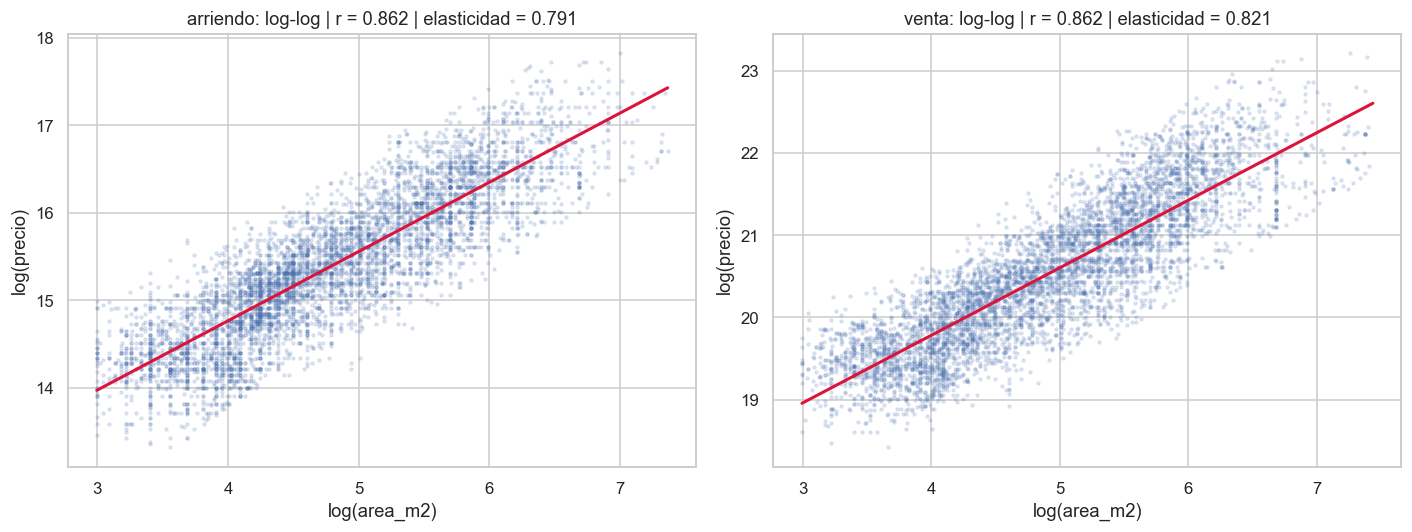

In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
for eje, (nombre, marco) in zip(ejes, MARCOS.items()):
    muestra = marco.sample(min(6000, len(marco)), random_state=0)
    eje.scatter(muestra["log_area"], muestra["log_precio"], s=4, alpha=.15, color="#4C72B0")
    pendiente, intercepto = np.polyfit(marco["log_area"], marco["log_precio"], 1)
    grilla = np.linspace(marco["log_area"].min(), marco["log_area"].max(), 50)
    eje.plot(grilla, pendiente * grilla + intercepto, color="crimson", lw=2)
    correlacion = marco[["log_area", "log_precio"]].corr().iloc[0, 1]
    eje.set_title(f"{nombre}: log-log | r = {correlacion:.3f} | elasticidad = {pendiente:.3f}")
    eje.set_xlabel("log(area_m2)")
    eje.set_ylabel("log(precio)")
plt.tight_layout()
plt.show()

## 5. Dos trampas para el modelo: censura y economías de escala

**Trampa 1 — las variables de conteo están censuradas en el origen.** El filtro de metrocuadrado
agrupa en "5 o más" y "4 o más", así que `habitaciones` y `banos` topan en 5 y `parqueaderos` en 4.
Se nota en la acumulación anómala justo en el tope. El transform ya lo dejó marcado en
`habitaciones_es_tope`, `banos_es_tope` y `parqueaderos_es_tope`.

`habitaciones = 5` **no significa 5, significa ">= 5"**. Tratarlo como numérico continuo hace que el
modelo aplane la cola alta. Las banderas `*_es_tope` deben entrar como features: le dicen al modelo
"acá el valor está truncado".

**Trampa 2 — el precio por m² no es constante.** Cae de forma sistemática a medida que crece el área:
un apartaestudio de 40 m² vale mucho más por m² que una casa de 400 m². Por eso la elasticidad del
§4 es menor que 1. Un modelo lineal en nivel no captura esto; en log–log sí, y un modelo de árboles
lo aprende solo.

**`parqueaderos` tiene 20,2 % de nulos**, y es ausencia real del dato, no error de parseo (se validó
contra el slug de la URL en `eda_raw_data.ipynb`). Imputar con la media inventa parqueaderos donde el
anunciante no declaró ninguno. Mejor: dejar el `NaN` y usar un modelo que lo maneje nativamente
(`HistGradientBoostingRegressor` lo hace).

habitaciones  {np.int8(1): 8809, np.int8(2): 6305, np.int8(3): 16917, np.int8(4): 7781, np.int8(5): 4967, <NA>: 54}
              en el tope: 11.08 % | nulos:  0.12 %
banos         {np.int8(1): 7646, np.int8(2): 13349, np.int8(3): 8283, np.int8(4): 7559, np.int8(5): 7962, <NA>: 34}
              en el tope: 17.76 % | nulos:  0.08 %
parqueaderos  {np.int8(1): 15077, np.int8(2): 10883, np.int8(3): 3296, np.int8(4): 6515, <NA>: 9062}
              en el tope: 14.53 % | nulos: 20.21 %


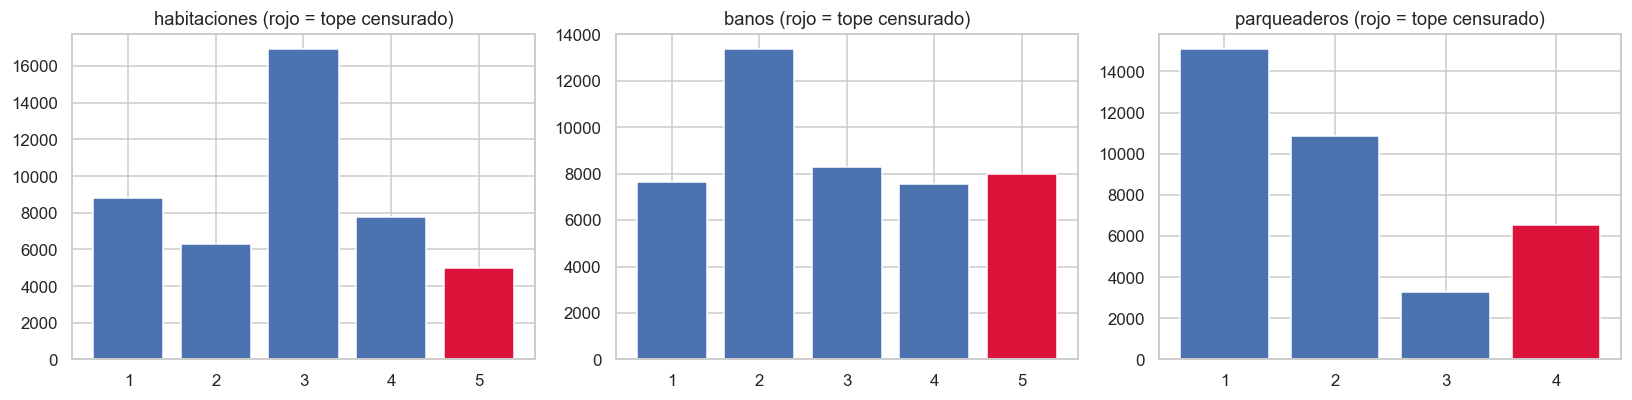

In [10]:
for columna in ["habitaciones", "banos", "parqueaderos"]:
    conteo = df[columna].value_counts(dropna=False).sort_index()
    print(f"{columna:13} {conteo.to_dict()}")
    print(f"{'':13} en el tope: {df[columna + '_es_tope'].mean() * 100:5.2f} % | nulos: {df[columna].isna().mean() * 100:5.2f} %")

fig, ejes = plt.subplots(1, 3, figsize=(15, 3.8))
for eje, columna in zip(ejes, ["habitaciones", "banos", "parqueaderos"]):
    conteo = df[columna].value_counts().sort_index()
    colores = ["#4C72B0"] * (len(conteo) - 1) + ["crimson"]
    eje.bar(conteo.index.astype(str), conteo.values, color=colores)
    eje.set_title(f"{columna} (rojo = tope censurado)")
plt.tight_layout()
plt.show()

=== ARRIENDO: precio/m² mediano por tramo de área ===


tipo_inmueble,apartaestudio,apartamento,casa
tramo_area,,,
"(20, 40]",57143.0,52715.0,<NA>
"(40, 60]",51020.0,35714.0,31417.0
"(60, 80]",57143.0,45420.0,35000.0
"(80, 120]",50556.0,47414.0,29661.0
"(120, 180]",50806.0,45600.0,31515.0
"(180, 250]",<NA>,51266.0,32500.0
"(250, 400]",<NA>,48611.0,33898.0
"(400, 700]",<NA>,<NA>,29340.0
"(700, 1800]",<NA>,<NA>,19659.0


=== VENTA: precio/m² mediano por tramo de área ===


tipo_inmueble,apartaestudio,apartamento,casa
tramo_area,,,
"(20, 40]",9221803.0,8160256.0,<NA>
"(40, 60]",8076923.0,5263158.0,5517241.0
"(60, 80]",8032258.0,6687500.0,4928138.0
"(80, 120]",7094551.0,6878762.0,4761905.0
"(120, 180]",5501935.0,7142857.0,4939338.0
"(180, 250]",<NA>,7173913.0,4898798.0
"(250, 400]",<NA>,8306709.0,5049282.0
"(400, 700]",<NA>,8324822.0,5348837.0
"(700, 1800]",<NA>,<NA>,3000000.0


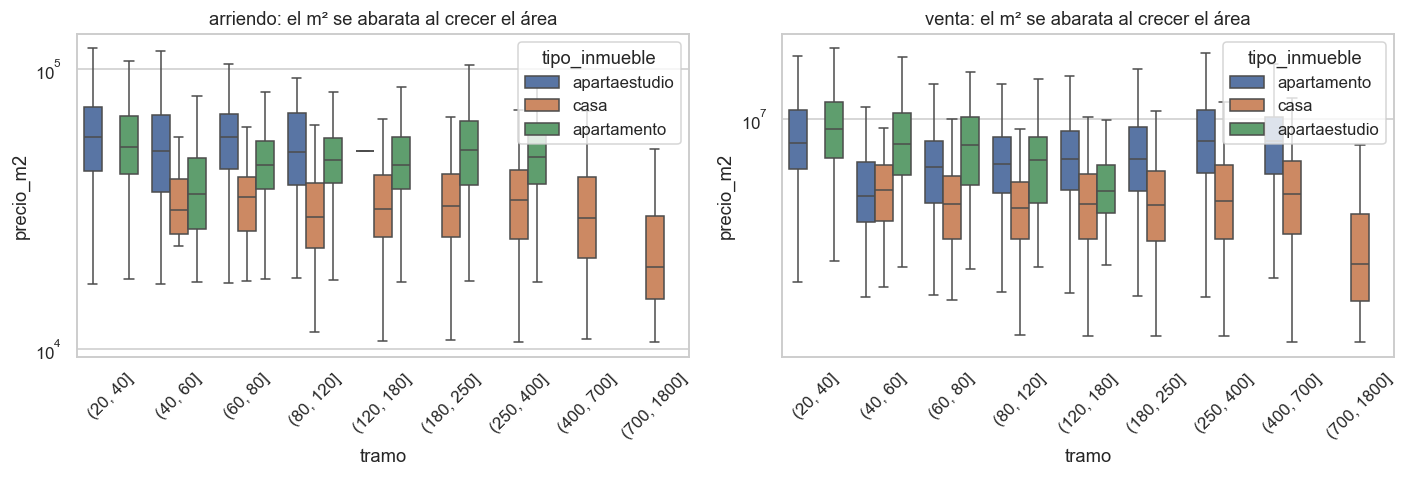

In [11]:
# Economías de escala: precio/m² mediano por tramo de área.
tramos = [20, 40, 60, 80, 120, 180, 250, 400, 700, 1800]
for nombre, marco in MARCOS.items():
    tabla = (marco.assign(tramo_area=pd.cut(marco["area_m2"], tramos))
             .groupby(["tramo_area", "tipo_inmueble"], observed=True)["precio_m2"]
             .median().unstack().round(0))
    print(f"=== {nombre.upper()}: precio/m² mediano por tramo de área ===")
    display(tabla)

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
for eje, (nombre, marco) in zip(ejes, MARCOS.items()):
    datos = marco.assign(tramo=pd.cut(marco["area_m2"], tramos))
    sns.boxplot(data=datos, x="tramo", y="precio_m2", hue="tipo_inmueble", ax=eje, showfliers=False)
    eje.set_title(f"{nombre}: el m² se abarata al crecer el área")
    eje.tick_params(axis="x", rotation=45)
    eje.set_yscale("log")
plt.tight_layout()
plt.show()

## 6. ⭐ Cuánto explica la ubicación — y por qué hoy no la podés usar

**Esta es la celda que justifica todo el resto del notebook.**

La pregunta es simple: ¿cuánta de la variación de `log(precio/m²)` explica saber dónde queda el
inmueble? La medimos de dos formas, y la diferencia entre ambas es todo el argumento.

- **R² in-sample**: se calcula la media del grupo con *todas* las filas y se evalúa sobre esas mismas
  filas. Es lo que un modelo mediría si lo dejás memorizar.
- **R² out-of-fold**: la media de cada grupo se calcula **solo con el train** de cada fold, y se
  evalúa contra el test. Es lo que realmente vas a obtener con datos nuevos.

Si las dos coinciden, la variable generaliza. Si se separan, la variable está memorizando.

El resultado (venta):

| Predictor | niveles | R² in-sample | R² out-of-fold | brecha |
|---|---|---|---|---|
| `tipo_inmueble` | 3 | 0,214 | **0,214** | 0,000 ✅ |
| `ciudad` | 217 | 0,248 | **0,232** | 0,016 ✅ |
| `ciudad + tipo` | 368 | 0,441 | **0,420** | 0,021 ✅ |
| `ciudad + sector` | 6.133 | 0,638 | **0,320** | **0,319** ❌ |

Leelo de arriba abajo. Las tres primeras filas tienen brecha ≈ 0: lo que explican, lo explican **de
verdad**. `ciudad + tipo` llega a 0,42 out-of-fold con apenas 368 niveles — ese es el techo honesto
de lo que hoy sabés sobre la ubicación.

La última fila es otra cosa. El sector explica 0,647 dentro de muestra y **pierde la mitad** al
salir. La causa está en la §2: **3.948 grupos tienen una sola fila**. Para esos, "la media del grupo"
ES el valor de la fila — R² 1,0 en train, cero información en test. Es memorización con nombre
elegante.

**La conclusión es la clave del proyecto:** la ubicación es, de lejos, la variable más informativa
que tenés (explica ~3× lo que explica la ciudad sola). Pero está codificada como un string de
altísima cardinalidad, y en ese formato **es inutilizable**.

La salida no es limpiar mejor el string. Es convertir la ubicación en **variables numéricas y
densas** — estrato, conteo de POIs, distancia al centro — donde miles de sectores distintos colapsan
en un puñado de dimensiones continuas que sí generalizan. Eso es exactamente lo que prueba la Parte B.

In [12]:
from sklearn.model_selection import KFold


def r2_codificacion(y, llaves, folds=5, semilla=0):
    """R² de predecir `y` con la media por grupo: dentro de muestra y fuera de muestra."""
    y = np.asarray(y, dtype="float64")
    # `sector_clave` tiene ~1 % de nulos y el concat propaga pd.NA. Sin este fillna,
    # groupby descarta esas llaves, transform devuelve NaN y el R² sale NaN.
    llaves = pd.Series(llaves).astype(object).fillna("__sin_dato__").astype(str).reset_index(drop=True)
    total = ((y - y.mean()) ** 2).sum()

    dentro = pd.Series(y).groupby(llaves).transform("mean").to_numpy()
    r2_dentro = 1 - ((y - dentro) ** 2).sum() / total

    fuera = np.empty(len(y))
    for train, test in KFold(folds, shuffle=True, random_state=semilla).split(y):
        medias = pd.Series(y[train]).groupby(llaves[train].reset_index(drop=True)).mean()
        fuera[test] = llaves[test].map(medias).fillna(y[train].mean()).to_numpy()
    r2_fuera = 1 - ((y - fuera) ** 2).sum() / total
    return r2_dentro, r2_fuera


filas = []
for nombre, marco in MARCOS.items():
    y = marco["log_precio_m2"].to_numpy()
    candidatos = {
        "tipo_inmueble": marco["tipo_inmueble"].astype(str),
        "ciudad": marco["ciudad_clave"].astype(str),
        "ciudad + tipo": marco["ciudad_clave"].astype(str) + "|" + marco["tipo_inmueble"].astype(str),
        "ciudad + sector": marco["ciudad_clave"].astype(str) + "|" + marco["sector_clave"].astype(str),
    }
    for etiqueta, llaves in candidatos.items():
        dentro, fuera = r2_codificacion(y, llaves)
        filas.append({
            "operacion": nombre, "predictor": etiqueta, "niveles": llaves.nunique(),
            "R2_in_sample": round(dentro, 3), "R2_out_of_fold": round(fuera, 3),
            "brecha": round(dentro - fuera, 3),
        })

comparacion = pd.DataFrame(filas)
display(comparacion)

,operacion,predictor,niveles,R2_in_sample,R2_out_of_fold,brecha
0,arriendo,tipo_inmueble,3,0.225,0.225,0.000
1,arriendo,ciudad,126,0.224,0.214,0.010
2,arriendo,ciudad + tipo,238,0.420,0.404,0.016
3,arriendo,ciudad + sector,4065,0.534,0.299,0.235
4,venta,tipo_inmueble,3,0.214,0.214,0.000
5,venta,ciudad,217,0.248,0.232,0.016
6,venta,ciudad + tipo,368,0.441,0.420,0.021
7,venta,ciudad + sector,6133,0.638,0.320,0.319


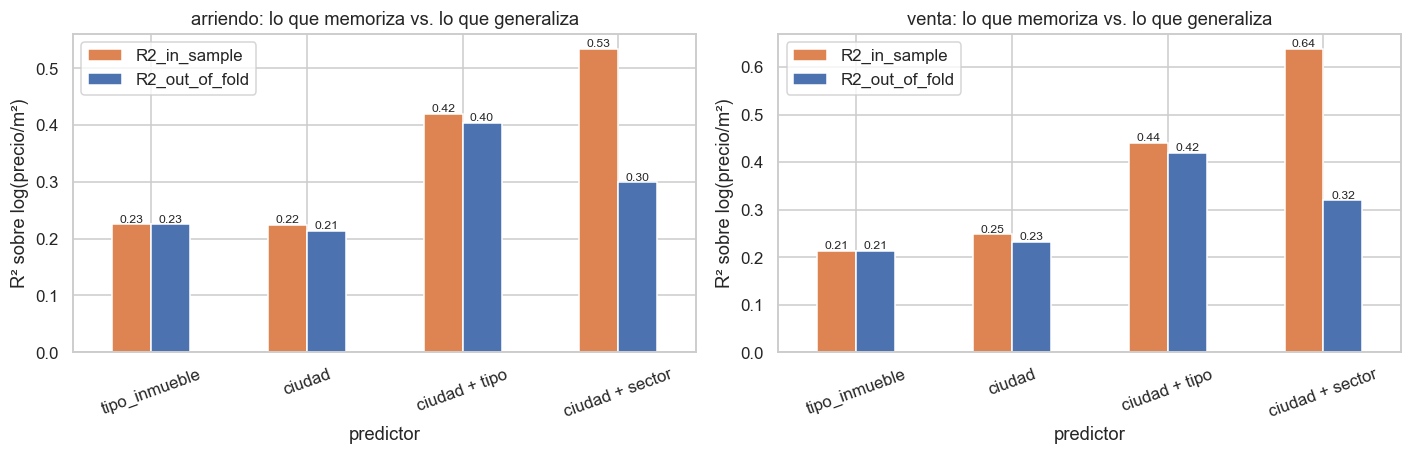

sectores con n >=  1:  6133 grupos | 22,519 filas (98.9 %) | R2 in=0.644 out=0.322 | brecha=0.321
sectores con n >=  2:  2185 grupos | 18,571 filas (81.5 %) | R2 in=0.547 out=0.403 | brecha=0.144
sectores con n >=  5:   795 grupos | 15,022 filas (66.0 %) | R2 in=0.487 out=0.420 | brecha=0.067
sectores con n >= 10:   404 grupos | 12,502 filas (54.9 %) | R2 in=0.463 out=0.426 | brecha=0.038
sectores con n >= 30:   109 grupos |  7,729 filas (33.9 %) | R2 in=0.421 out=0.405 | brecha=0.016


In [13]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.3))
for eje, nombre in zip(ejes, MARCOS):
    sub = comparacion[comparacion["operacion"] == nombre].set_index("predictor")
    sub[["R2_in_sample", "R2_out_of_fold"]].plot.bar(ax=eje, color=["#DD8452", "#4C72B0"], rot=20)
    eje.set_title(f"{nombre}: lo que memoriza vs. lo que generaliza")
    eje.set_ylabel("R² sobre log(precio/m²)")
    for contenedor in eje.containers:
        eje.bar_label(contenedor, fmt="%.2f", fontsize=8)
plt.tight_layout()
plt.show()

# De dónde sale la brecha: los grupos chicos son puro ruido memorizado.
marco = MARCOS["venta"]
llaves = marco["ciudad_clave"].astype(str) + "|" + marco["sector_clave"].astype(str)
tam = llaves.value_counts()
for corte in [1, 2, 5, 10, 30]:
    grandes = set(tam[tam >= corte].index)
    mascara = llaves.isin(grandes)
    dentro, fuera = r2_codificacion(marco.loc[mascara, "log_precio_m2"], llaves[mascara])
    print(f"sectores con n >= {corte:2}: {len(grandes):5} grupos | {mascara.sum():6,} filas"
          f" ({mascara.mean() * 100:4.1f} %) | R2 in={dentro:.3f} out={fuera:.3f} | brecha={dentro - fuera:.3f}")

## 7. Baseline honesto (y por qué el split random miente)

Antes de proponer enriquecimiento hay que fijar **contra qué se compara**. Un baseline con lo que ya
hay: área, conteos, banderas de censura, tipo y ciudad.

Un detalle que cambia el resultado: **el 8–12 % de las filas son near-duplicados** — mismo
`ciudad + sector + tipo + área + precio`. Son unidades del mismo proyecto publicadas por separado, o
el mismo anuncio republicado. Con un split aleatorio, la unidad 3 del proyecto queda en train y la
unidad 7 en test: el modelo ya vio la respuesta. La métrica sube y **te miente**.

Por eso el baseline se evalúa con `GroupKFold` agrupando por esa llave. Es más bajo. Es el real.

Se reporta MAE en escala log (≈ error relativo: 0,20 en log ≈ 20 % de error típico) y MAPE en pesos.

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold


def llave_duplicado(marco):
    """Agrupa near-duplicados: mismo proyecto/anuncio republicado."""
    return (marco["ciudad_clave"].astype(str) + "|" + marco["sector_clave"].astype(str) + "|"
            + marco["tipo_inmueble"].astype(str) + "|" + marco["area_m2"].astype(str) + "|"
            + marco["precio"].astype(str))


BASE_NUMERICAS = ["log_area", "habitaciones", "banos", "parqueaderos"]
BASE_BANDERAS = ["habitaciones_es_tope", "banos_es_tope", "parqueaderos_es_tope"]


def matriz(marco, extras=()):
    X = marco[BASE_NUMERICAS].astype("float64").copy()
    for columna in BASE_BANDERAS:
        X[columna] = marco[columna].astype("float64")
    for columna in ["tipo_inmueble", "ciudad_clave"]:
        X[columna] = marco[columna].astype("category").cat.codes.astype("float64")
    for columna in extras:
        X[columna] = pd.to_numeric(marco[columna], errors="coerce").astype("float64")
    return X


def evaluar(marco, extras=(), etiqueta="", folds=5):
    X = matriz(marco, extras)
    y = marco["log_precio"].to_numpy()
    grupos = llave_duplicado(marco).factorize()[0]
    categoricas = [X.columns.get_loc(c) for c in ["tipo_inmueble", "ciudad_clave"]]

    prediccion = np.empty(len(y))
    for train, test in GroupKFold(folds).split(X, y, grupos):
        modelo = HistGradientBoostingRegressor(
            max_iter=400, learning_rate=.06, max_depth=None,
            categorical_features=categoricas, random_state=0)
        modelo.fit(X.iloc[train], y[train])
        prediccion[test] = modelo.predict(X.iloc[test])

    r2 = 1 - ((y - prediccion) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    mae_log = np.abs(y - prediccion).mean()
    mape = (np.abs(np.expm1(prediccion - y))).mean() * 100
    print(f"{etiqueta:34} n={len(y):6,} features={X.shape[1]:2}"
          f" | R2={r2:.3f} | MAE(log)={mae_log:.3f} | MAPE~{mape:.1f} %")
    return {"etiqueta": etiqueta, "n": len(y), "R2": round(r2, 3),
            "MAE_log": round(mae_log, 3), "MAPE_%": round(mape, 1)}


print("Baseline agrupado por near-duplicado (GroupKFold) — el número honesto:\n")
baseline = {nombre: evaluar(marco, etiqueta=f"{nombre}: baseline (5 features + ciudad)")
            for nombre, marco in MARCOS.items()}

Baseline agrupado por near-duplicado (GroupKFold) — el número honesto:

arriendo: baseline (5 features + ciudad) n=22,059 features= 9 | R2=0.863 | MAE(log)=0.229 | MAPE~23.4 %
venta: baseline (5 features + ciudad) n=22,774 features= 9 | R2=0.881 | MAE(log)=0.227 | MAPE~23.3 %


In [15]:
# Cuánto infla la métrica un split aleatorio ingenuo. Esta es la diferencia entre
# el número que ponés en el informe y el que vas a ver en producción.
from sklearn.model_selection import cross_val_predict

for nombre, marco in MARCOS.items():
    duplicadas = llave_duplicado(marco).duplicated(keep=False)
    X, y = matriz(marco), marco["log_precio"].to_numpy()
    categoricas = [X.columns.get_loc(c) for c in ["tipo_inmueble", "ciudad_clave"]]
    modelo = HistGradientBoostingRegressor(max_iter=400, learning_rate=.06,
                                           categorical_features=categoricas, random_state=0)
    prediccion = cross_val_predict(modelo, X, y, cv=KFold(5, shuffle=True, random_state=0))
    r2_ingenuo = 1 - ((y - prediccion) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    print(f"{nombre:9} | near-duplicados: {duplicadas.mean() * 100:4.1f} %"
          f" | R2 con split aleatorio: {r2_ingenuo:.3f}"
          f" | R2 agrupado (real): {baseline[nombre]['R2']:.3f}"
          f" | inflado en {r2_ingenuo - baseline[nombre]['R2']:+.3f}")

arriendo  | near-duplicados: 11.6 % | R2 con split aleatorio: 0.864 | R2 agrupado (real): 0.863 | inflado en +0.001
venta     | near-duplicados:  8.6 % | R2 con split aleatorio: 0.882 | R2 agrupado (real): 0.881 | inflado en +0.001


---

# Parte B — Prototipo de enriquecimiento geoespacial

> ⚠️ **A partir de acá las celdas hacen llamadas de red.** Todas las respuestas se cachean en
> `data/external/`; con el caché escrito, las celdas vuelven a correr sin tocar internet.

La Parte A dejó el diagnóstico: la ubicación es la variable con más señal y está en un formato que no
generaliza. La Parte B prueba si se puede arreglar con datos de OpenStreetMap.

**Primer obstáculo: no hay coordenadas.** El dataset tiene `ciudad` y `sector` como texto y nada más.
Sin lat/lon no hay búsqueda de POIs posible. Geocodificar es el paso cero.

**Qué se probó y qué se descartó:**

`Nominatim` con query libre (`"medellin, laureles"`) **no sirve** para esto. Devuelve el primer
resultado que matchea el texto, y en Colombia eso suele ser un negocio cuyo *nombre* contiene el
barrio, no el barrio:

| query | primer resultado | ¿sirve? |
|---|---|---|
| `medellin, laureles` | `shop/beauty` — un salón de belleza | ❌ |
| `bogota d.c., cedritos` | `amenity/pub` — Bogota Beer Company | ❌ |
| `bogota d.c., villa del prado` | un restaurante ubicado en **Nueva Zelandia** | ❌ centroide equivocado |
| `barranquilla, alto prado` | `tourism/hotel` | ❌ |

Filtrar por `class`/`type` deja casi todo sin resultado. Y aunque funcionara: **1 req/seg × 7.000
sectores ≈ 2 horas**.

**El camino que sí funciona: un gazetteer local por ciudad vía Overpass.** Una sola query por ciudad
trae *todos* los barrios (`place=suburb|neighbourhood|quarter`) con su centroide. Después el match
sector→barrio se hace **localmente**, sin red. Bogotá: 1.276 barrios en ~33 s.

**Tres notas operativas, todas aprendidas a los golpes:**

- `overpass-api.de` tiene el **certificado SSL vencido** (verificado 2026-09) → se usa
  `overpass.kumi.systems` como mirror principal.
- **Overpass asigna slots por IP.** Una query pesada consume el slot y la siguiente rebota unos
  segundos. No es un fallo permanente: `consultar_overpass()` reintenta con backoff en vez de
  abortar. Y como cada respuesta se cachea apenas llega, **si la corrida se corta, volver a ejecutar
  retoma donde quedó** — no re-descarga lo que ya bajó.
- **No se usa `osmnx`.** Arrastra GDAL, shapely y pyproj para algo que acá es contar elementos en un
  radio. OSMnx se justifica cuando necesitás la red vial y análisis de grafos — no es este caso.

In [16]:
import hashlib
import time
import unicodedata
import urllib.error
import urllib.parse
import urllib.request

EXTERNO.mkdir(parents=True, exist_ok=True)

# Medido el 2026-09-10 con la query de barrios de Bogotá:
#   private.coffee  57,6 s  OK   <- el más rápido, va primero
#   kumi.systems   164,7 s  OK   <- funciona pero al filo de cualquier timeout corto
#   overpass-api.de     --  SSL: certificate has expired
#   overpass.osm.jp     --  SSL: hostname mismatch
MIRRORS_OVERPASS = [
    "https://overpass.private.coffee/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
    "https://overpass-api.de/api/interpreter",
]
AGENTE = {"User-Agent": "valora-etl-pipeline/0.1 (EDA academico; contacto via repo)"}
PAUSA_SEGUNDOS = 5
ESPERAS_REINTENTO = [0, 30, 90, 180]  # backoff entre vueltas completas a la lista de mirrors


def consultar_overpass(consulta, nombre_cache, espera=240):
    """Ejecuta una query Overpass con caché en disco. Con caché no toca la red.

    Overpass asigna *slots* por IP: una query pesada consume el slot y las
    siguientes rebotan por unos segundos. No es un fallo permanente, así que se
    reintenta con backoff en vez de abortar la corrida entera.
    """
    firma = hashlib.sha1(consulta.encode()).hexdigest()[:10]
    destino = EXTERNO / f"{nombre_cache}_{firma}.json"
    if destino.exists():
        return json.loads(destino.read_text(encoding="utf-8")), True

    cuerpo = urllib.parse.urlencode({"data": consulta}).encode()
    for vuelta, pausa in enumerate(ESPERAS_REINTENTO):
        if pausa:
            print(f"  todos los mirrors ocupados; reintento {vuelta} en {pausa} s…")
            time.sleep(pausa)
        for mirror in MIRRORS_OVERPASS:
            try:
                peticion = urllib.request.Request(mirror, data=cuerpo, headers=AGENTE)
                with urllib.request.urlopen(peticion, timeout=espera) as respuesta:
                    datos = json.load(respuesta)
                destino.write_text(json.dumps(datos), encoding="utf-8")
                time.sleep(PAUSA_SEGUNDOS)
                return datos, False
            except (urllib.error.URLError, TimeoutError, json.JSONDecodeError) as error:
                detalle = getattr(error, "code", type(error).__name__)
                print(f"  {mirror.split('/')[2]} -> {detalle}")
    raise RuntimeError(
        f"Overpass no respondió para '{nombre_cache}' tras {len(ESPERAS_REINTENTO)} vueltas. "
        "Lo ya descargado quedó en data/external/: volver a correr la celda retoma desde ahí.")


def normalizar(texto):
    """Sin tildes, minúsculas, solo alfanumérico. Para comparar nombres de barrio."""
    sin_tildes = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode().lower()
    solo_alfanumerico = "".join(c if c.isalnum() else " " for c in sin_tildes)
    return " ".join(solo_alfanumerico.split())


print("caché en:", EXTERNO)
print("archivos cacheados:", len(list(EXTERNO.glob("*.json"))))

caché en: C:\Users\juanj\Desktop\valora-etl-pipeline\data\external
archivos cacheados: 10


## 8. Gazetteer de barrios por ciudad

Un bounding box por ciudad y una query Overpass que devuelve todo nodo, vía o relación taggeada como
barrio, con su centroide.

Se corre sobre las **5 ciudades principales** (≈ 65 % de los anuncios), no sobre las 231. El
prototipo tiene que medir viabilidad y lift, no cubrir el país — si el lift aparece, la extensión al
resto es mecánica.

In [17]:
# Bounding boxes (sur, oeste, norte, este) del área urbana de cada ciudad.
BBOX_CIUDADES = {
    "bogota d.c.":  (4.45, -74.25, 4.84, -74.00),
    "medellin":     (6.15, -75.65, 6.38, -75.48),
    "envigado":     (6.12, -75.62, 6.21, -75.51),
    "barranquilla": (10.88, -74.89, 11.06, -74.72),
    "cali":         (3.32, -76.58, 3.53, -76.44),
}

CONSULTA_BARRIOS = """[out:json][timeout:180];
(node({bbox})["place"~"^(suburb|neighbourhood|quarter|borough)$"];
 way({bbox})["place"~"^(suburb|neighbourhood|quarter|borough)$"];
 relation({bbox})["place"~"^(suburb|neighbourhood|quarter|borough)$"];);
out center tags;"""


def gazetteer_ciudad(ciudad, bbox):
    consulta = CONSULTA_BARRIOS.format(bbox=",".join(str(v) for v in bbox))
    datos, desde_cache = consultar_overpass(consulta, f"barrios_{ciudad.replace(' ', '_').replace('.', '')}")
    filas = []
    for elemento in datos["elements"]:
        etiquetas = elemento.get("tags", {})
        nombre = etiquetas.get("name")
        if not nombre:
            continue
        centro = elemento.get("center", elemento)
        if centro.get("lat") is None:
            continue
        filas.append({"ciudad_clave": ciudad, "barrio": nombre, "barrio_norm": normalizar(nombre),
                      "lat": centro["lat"], "lon": centro["lon"], "place": etiquetas["place"]})
    marco = pd.DataFrame(filas).drop_duplicates("barrio_norm")
    print(f"  {ciudad:14} {len(marco):5} barrios {'(caché)' if desde_cache else '(red)'}")
    return marco


print("Descargando gazetteer OSM…")
gazetteer = pd.concat([gazetteer_ciudad(ciudad, bbox) for ciudad, bbox in BBOX_CIUDADES.items()],
                      ignore_index=True)
print(f"\ntotal barrios: {len(gazetteer):,}")
display(gazetteer["place"].value_counts().to_frame("barrios"))
display(gazetteer.head())

Descargando gazetteer OSM…
  bogota d.c.     1162 barrios (caché)
  medellin         324 barrios (caché)
  envigado          37 barrios (caché)
  barranquilla     410 barrios (caché)
  cali             359 barrios (caché)

total barrios: 2,292


,barrios
place,
neighbourhood,2093
quarter,121
suburb,78


,ciudad_clave,barrio,barrio_norm,lat,lon,place
0,bogota d.c.,Marsella,marsella,4.632064,-74.130404,neighbourhood
1,bogota d.c.,Villa Alsacia,villa alsacia,4.642629,-74.136769,neighbourhood
2,bogota d.c.,Las Dos Avenidas,las dos avenidas,4.635242,-74.138757,neighbourhood
3,bogota d.c.,El Nogal,el nogal,4.660321,-74.053564,neighbourhood
4,bogota d.c.,Egipto,egipto,4.593094,-74.069803,neighbourhood


## 9. Match sector → barrio

Dos pasadas: match exacto sobre el nombre normalizado y, para lo que queda, `difflib`.

**Sobre el fuzzy hay que ser desconfiado, y los números lo confirmaron.**

Primer intento con cutoff **0,86**: sumó apenas +4 % de cobertura y produjo `lago gaitan` → `la
gaitana` y `el salitre` → `el satelite`, que son **barrios distintos**. Se subió a **0,92**. Mejoró,
pero no lo suficiente:

| sector | match propuesto | ¿correcto? |
|---|---|---|
| `saan jose de bavaria` | `san jose de bavaria` | ✅ typo del anunciante |
| `cedritios` / `cedrito` | `cedritos` | ✅ typo |
| `bella vista` | `bellavista` | ✅ espaciado |
| `ciudad salitre nororiental` | `ciudad salitre suroriental` | ❌ **norte vs. sur** |
| `rio negro` | `rionegro` | ❌ **Rionegro es otro municipio** |
| `osorio xiii` | `osorio iii` | ❌ numeración romana distinta |
| `san bernardino xxv` | `san bernardino xix` | ❌ ídem |

Y acá está el problema de fondo: **`difflib` compara caracteres, no geografía.** Justo los casos que
más se parecen como texto (`xiii`/`iii`, `nororiental`/`suroriental`) son los que más lejos quedan en
el mapa. Un centroide equivocado no es un dato ruidoso — es un dato **falso**, y el modelo lo aprende
como verdad.

Los matches fuzzy quedan **marcados aparte** y el §11 mide el lift con y sin ellos. **Spoiler: no
pagan.** Aportan 0,7 % de cobertura y en arriendo el R² *baja* (0,877 solo-exacto vs. 0,874 con
fuzzy). Cuando el dato extra empeora el modelo, la decisión ya no es de opinión.

Se reporta cobertura **por filas**, no por sectores únicos — es lo que le importa al modelo.

In [18]:
import difflib

# 0,86 producía "el salitre" -> "el satelite". A 0,92 solo pasan variantes ortográficas.
CORTE_FUZZY = 0.92
ciudades_prototipo = list(BBOX_CIUDADES)
subconjunto = df[df["ciudad_clave"].isin(ciudades_prototipo) & df["sector_clave"].notna()].copy()
subconjunto["sector_norm"] = subconjunto["sector_clave"].map(normalizar)

resoluciones, ejemplos_fuzzy = {}, []
for ciudad in ciudades_prototipo:
    barrios = gazetteer[gazetteer["ciudad_clave"] == ciudad]
    indice = dict(zip(barrios["barrio_norm"], zip(barrios["lat"], barrios["lon"])))
    claves = list(indice)
    for sector in subconjunto.loc[subconjunto["ciudad_clave"] == ciudad, "sector_norm"].unique():
        if sector in indice:
            resoluciones[(ciudad, sector)] = (*indice[sector], "exacto")
        else:
            candidato = difflib.get_close_matches(sector, claves, n=1, cutoff=CORTE_FUZZY)
            if candidato:
                resoluciones[(ciudad, sector)] = (*indice[candidato[0]], "fuzzy")
                ejemplos_fuzzy.append((ciudad, sector, candidato[0]))

llave = list(zip(subconjunto["ciudad_clave"], subconjunto["sector_norm"]))
subconjunto["lat"] = [resoluciones.get(k, (np.nan,) * 3)[0] for k in llave]
subconjunto["lon"] = [resoluciones.get(k, (np.nan,) * 3)[1] for k in llave]
subconjunto["match"] = [resoluciones.get(k, (None, None, "sin_match"))[2] for k in llave]

print(f"prototipo: {len(subconjunto):,} filas en {len(ciudades_prototipo)} ciudades"
      f" ({len(subconjunto) / len(df) * 100:.1f} % del dataset)\n")
display(subconjunto["match"].value_counts(normalize=True).mul(100).round(1).to_frame("% de filas"))
display(pd.crosstab(subconjunto["ciudad_clave"], subconjunto["match"], normalize="index").mul(100).round(1))
print("\nMuestra de matches fuzzy (auditar a ojo):")
for ciudad, sector, barrio in ejemplos_fuzzy[:15]:
    print(f"  {ciudad:14} {sector:32} -> {barrio}")

prototipo: 29,532 filas en 5 ciudades (65.9 % del dataset)



,% de filas
match,
sin_match,55.4
exacto,43.9
fuzzy,0.7


match,exacto,fuzzy,sin_match
ciudad_clave,,,
barranquilla,82.9,1.4,15.7
bogota d.c.,32.0,0.8,67.2
cali,44.5,1.9,53.6
envigado,3.6,0.0,96.4
medellin,66.5,0.2,33.3



Muestra de matches fuzzy (auditar a ojo):
  bogota d.c.    ciudad salitre occidental        -> upz ciudad salitre occidental
  bogota d.c.    ciudad salitre nororiental       -> ciudad salitre suroriental
  bogota d.c.    jj vargas                        -> j j vargas
  bogota d.c.    rio negro                        -> rionegro
  bogota d.c.    cedrito                          -> cedritos
  bogota d.c.    cedritios                        -> cedritos
  bogota d.c.    osorio xiii                      -> osorio iii
  bogota d.c.    san bernardino xxv               -> san bernardino xix
  bogota d.c.    saan jose de bavaria             -> san jose de bavaria
  bogota d.c.    ciudad salitre oriental          -> ciudad salitre suroriental
  bogota d.c.    santa helenita                   -> santa helena
  bogota d.c.    localidad de chapinero           -> localidad chapinero
  bogota d.c.    bella vista                      -> bellavista
  bogota d.c.    motevideo                        ->

## 10. Puntos de interés por barrio

El enfoque obvio sería una query `around:1000` por barrio. **Se probó y no escala**: 41,8 s por
barrio × ~500 barrios ≈ **6 horas**, más el riesgo de que el mirror corte por abuso.

El enfoque correcto invierte el orden: **una sola query por ciudad** que baja *todos* los POIs del
bounding box, y después el conteo por radio se hace **localmente** con un KD-tree. Pasa de ~500
requests a **5**, y el conteo tarda milisegundos.

Detalle de proyección: un KD-tree necesita un plano cartesiano, no grados. Se proyecta a metros con
la aproximación local plana (1° lat ≈ 111,32 km; 1° lon ≈ 111,32 km × cos(lat)). A escala de ciudad
y con radio de 1 km, el error es despreciable — no hace falta pyproj.

Las categorías salen de lo que efectivamente mueve el precio de vivienda:

| columna | tags OSM | por qué |
|---|---|---|
| `n_parques` | `leisure=park` | espacio verde, valoriza |
| `n_transporte` | `public_transport=station`, `highway=bus_stop` | conectividad |
| `n_bancos` | `amenity=bank` | proxy de centralidad comercial |
| `n_supermercados` | `shop=supermarket\|convenience` | servicios básicos |
| `n_restaurantes` | `amenity=restaurant\|cafe` | vida de barrio, gentrificación |
| `n_colegios` | `amenity=school\|kindergarten` | demanda familiar |
| `n_salud` | `amenity=hospital\|clinic\|pharmacy` | servicios de salud |

Un detalle nada menor: **la densidad de POIs en OSM también mide cuánto mapeó la comunidad esa zona.**
Los barrios ricos de Bogotá están mucho mejor mapeados que la periferia. Parte de lo que capture esta
feature es señal real de equipamiento, y parte es sesgo de cobertura de OSM — que, incómodamente,
correlaciona con el precio. Vale como feature predictiva; **no vale como afirmación causal.**

In [19]:
CATEGORIAS_POI = {
    "n_parques":       ['["leisure"="park"]'],
    "n_transporte":    ['["public_transport"="station"]', '["highway"="bus_stop"]'],
    "n_bancos":        ['["amenity"="bank"]'],
    "n_supermercados": ['["shop"~"^(supermarket|convenience)$"]'],
    "n_restaurantes":  ['["amenity"~"^(restaurant|cafe)$"]'],
    "n_colegios":      ['["amenity"~"^(school|kindergarten)$"]'],
    "n_salud":         ['["amenity"~"^(hospital|clinic|pharmacy)$"]'],
}
RADIO_METROS = 1000
GRADO_EN_METROS = 111_320.0


def clasificar(etiquetas):
    """Devuelve las categorías a las que pertenece un elemento OSM (puede ser más de una)."""
    amenidad, tienda = etiquetas.get("amenity"), etiquetas.get("shop")
    encontradas = []
    if etiquetas.get("leisure") == "park":
        encontradas.append("n_parques")
    if etiquetas.get("public_transport") == "station" or etiquetas.get("highway") == "bus_stop":
        encontradas.append("n_transporte")
    if amenidad == "bank":
        encontradas.append("n_bancos")
    if tienda in {"supermarket", "convenience"}:
        encontradas.append("n_supermercados")
    if amenidad in {"restaurant", "cafe"}:
        encontradas.append("n_restaurantes")
    if amenidad in {"school", "kindergarten"}:
        encontradas.append("n_colegios")
    if amenidad in {"hospital", "clinic", "pharmacy"}:
        encontradas.append("n_salud")
    return encontradas


def descargar_pois_ciudad(ciudad, bbox):
    """UNA query por ciudad con todos los POIs del bbox. El conteo por radio se hace local."""
    caja = ",".join(str(v) for v in bbox)
    partes = []
    for filtros in CATEGORIAS_POI.values():
        for filtro in filtros:
            partes.append(f"node({caja}){filtro};")
            partes.append(f"way({caja}){filtro};")
    consulta = "[out:json][timeout:180];(" + "".join(partes) + ");out tags center;"
    datos, desde_cache = consultar_overpass(consulta, f"pois_{ciudad.replace(' ', '_').replace('.', '')}")

    filas = []
    for elemento in datos["elements"]:
        centro = elemento.get("center", elemento)
        if centro.get("lat") is None:
            continue
        for categoria in clasificar(elemento.get("tags", {})):
            filas.append({"ciudad_clave": ciudad, "categoria": categoria,
                          "lat": centro["lat"], "lon": centro["lon"]})
    marco = pd.DataFrame(filas)
    print(f"  {ciudad:14} {len(marco):6,} POIs {'(caché)' if desde_cache else '(red)'}")
    return marco


print("Descargando POIs por ciudad (1 request por ciudad, no por barrio)…")
todos_pois = pd.concat([descargar_pois_ciudad(ciudad, bbox) for ciudad, bbox in BBOX_CIUDADES.items()],
                       ignore_index=True)
print(f"\ntotal POIs: {len(todos_pois):,}")
display(pd.crosstab(todos_pois["ciudad_clave"], todos_pois["categoria"]))

Descargando POIs por ciudad (1 request por ciudad, no por barrio)…
  bogota d.c.    20,629 POIs (caché)
  medellin        5,775 POIs (caché)
  envigado        1,052 POIs (caché)
  barranquilla    2,365 POIs (caché)
  cali            3,024 POIs (caché)

total POIs: 32,845


categoria,n_bancos,n_colegios,n_parques,n_restaurantes,n_salud,n_supermercados,n_transporte
ciudad_clave,,,,,,,
barranquilla,91,315,492,257,198,493,519
bogota d.c.,874,1603,4144,6014,1885,3287,2822
cali,133,156,183,450,565,224,1313
envigado,60,241,136,327,109,129,50
medellin,197,1233,1080,1319,597,902,447


In [20]:
from scipy.spatial import cKDTree

# Solo los barrios que efectivamente matchearon con algún anuncio.
coordenadas = (subconjunto.loc[subconjunto["match"] != "sin_match",
                               ["ciudad_clave", "lat", "lon"]]
               .drop_duplicates().reset_index(drop=True))


def contar_en_radio(centros, puntos, radio=RADIO_METROS):
    """Cuenta cuántos `puntos` caen dentro de `radio` de cada centro, vía KD-tree.

    Proyección plana local: suficiente a escala de ciudad, sin necesidad de pyproj.
    """
    if len(puntos) == 0 or len(centros) == 0:
        return np.zeros(len(centros), dtype=int)
    lat_referencia = np.radians(centros[:, 0].mean())
    escala_lon = GRADO_EN_METROS * np.cos(lat_referencia)

    def proyectar(coords):
        return np.column_stack([coords[:, 1] * escala_lon, coords[:, 0] * GRADO_EN_METROS])

    arbol = cKDTree(proyectar(puntos))
    return np.array([len(v) for v in arbol.query_ball_point(proyectar(centros), r=radio)])


conteos = {categoria: np.zeros(len(coordenadas), dtype=int) for categoria in CATEGORIAS_POI}
for ciudad in coordenadas["ciudad_clave"].unique():
    mascara = (coordenadas["ciudad_clave"] == ciudad).to_numpy()
    centros = coordenadas.loc[mascara, ["lat", "lon"]].to_numpy()
    pois_ciudad = todos_pois[todos_pois["ciudad_clave"] == ciudad]
    for categoria in CATEGORIAS_POI:
        puntos = pois_ciudad.loc[pois_ciudad["categoria"] == categoria, ["lat", "lon"]].to_numpy()
        conteos[categoria][mascara] = contar_en_radio(centros, puntos)

pois = coordenadas.assign(**conteos)
pois["n_pois_total"] = pois[list(CATEGORIAS_POI)].sum(axis=1)
print(f"barrios con conteo de POIs: {len(pois):,} (radio {RADIO_METROS} m)\n")
display(pois[list(CATEGORIAS_POI) + ["n_pois_total"]].describe().round(1))

barrios con conteo de POIs: 684 (radio 1000 m)



,n_parques,n_transporte,n_bancos,n_supermercados,n_restaurantes,n_colegios,n_salud,n_pois_total
count,684.0,684.0,684.0,684.0,684.0,684.0,684.0,684.0
mean,24.2,21.7,6.3,21.2,37.7,13.0,15.3,139.3
std,18.8,15.5,8.3,18.8,59.6,10.4,13.9,102.2
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,8.0,9.0,1.0,7.0,6.0,5.0,5.0,72.8
50%,22.0,20.0,3.0,15.0,17.0,11.0,11.0,115.0
75%,36.0,32.0,9.0,32.0,44.0,17.2,22.0,182.0
max,107.0,82.0,58.0,99.0,477.0,56.0,81.0,791.0


In [21]:
enriquecido = subconjunto.merge(pois, on=["ciudad_clave", "lat", "lon"], how="left")
COLUMNAS_POI = list(CATEGORIAS_POI) + ["n_pois_total"]

print(f"filas con POIs: {enriquecido['n_pois_total'].notna().sum():,}"
      f" / {len(enriquecido):,} ({enriquecido['n_pois_total'].notna().mean() * 100:.1f} %)\n")

# ¿Correlacionan los POIs con el precio por m²? Se mide DENTRO de cada ciudad,
# para no confundir "más POIs" con "es Bogotá".
for nombre, columna in OPERACIONES.items():
    marco = enriquecido[enriquecido[columna].notna() & enriquecido["n_pois_total"].notna()].copy()
    marco["log_precio_m2"] = np.log(marco["precio_m2"].astype("float64"))
    correlaciones = {}
    for poi in COLUMNAS_POI:
        centrado = marco["log_precio_m2"] - marco.groupby("ciudad_clave")["log_precio_m2"].transform("mean")
        correlaciones[poi] = marco[poi].corr(centrado, method="spearman")
    print(f"{nombre.upper()} (n={len(marco):,}) — corr POI vs log(precio/m²) centrado por ciudad:")
    print(pd.Series(correlaciones).round(3).sort_values(ascending=False).to_string(), "\n")

filas con POIs: 13,181 / 29,532 (44.6 %)

ARRIENDO (n=7,458) — corr POI vs log(precio/m²) centrado por ciudad:
n_restaurantes     0.181
n_pois_total       0.089
n_salud            0.081
n_bancos           0.074
n_parques         -0.006
n_supermercados   -0.053
n_transporte      -0.067
n_colegios        -0.206 

VENTA (n=5,723) — corr POI vs log(precio/m²) centrado por ciudad:
n_restaurantes     0.249
n_bancos           0.202
n_salud            0.167
n_pois_total       0.166
n_supermercados    0.134
n_parques          0.097
n_transporte       0.086
n_colegios        -0.223 



### Lo que dicen esas correlaciones

Tres cosas que vale la pena mirar antes de seguir:

**`n_restaurantes` es el POI más correlacionado** (+0,18 arriendo, +0,25 venta, ya descontado el
efecto ciudad). Tiene sentido: la densidad gastronómica es el mejor proxy barato de zona consolidada
y con poder adquisitivo.

**`n_colegios` correlaciona NEGATIVO** (−0,21 / −0,22). No es un error de signo ni significa que los
colegios devalúen. Es geografía: los colegios grandes necesitan lotes grandes, y los lotes grandes
están donde el suelo es barato — periferia y zonas residenciales de menor densidad. La variable está
midiendo "lejos del centro", no "cerca de un colegio".

Es el recordatorio de siempre: **estas correlaciones son predictivas, no causales.** Ninguna de estas
columnas sostiene una frase del tipo "poner un banco valoriza el barrio".

**Ojo con la cobertura despareja** (§9): Barranquilla matcheó 82,9 % de sus filas y Envigado apenas
3,6 %. Envigado es un caso de nombre de sector que repite el de la ciudad (`envigado, envigado`) y de
un bbox que se solapa con Medellín. Cualquier conclusión por ciudad tiene que leerse junto a su
cobertura.

## 11. ¿El enriquecimiento paga? Medición del lift

La única pregunta que importa. Se re-corre **exactamente el mismo baseline del §7** — mismo modelo,
mismo `GroupKFold`, mismos hiperparámetros — sobre **el mismo subconjunto de filas**, cambiando solo
las features disponibles.

Tres escenarios:

1. **Baseline**: las features actuales.
2. **+ coordenadas**: agregando `lat`/`lon` del barrio. Le da al modelo la geografía real, y los
   árboles pueden partir el espacio en zonas.
3. **+ coordenadas + POIs**: el paquete completo.

Comparar sobre el mismo subconjunto es innegociable: si el baseline se mide sobre 44.833 filas y el
enriquecido sobre las 20.000 que matchearon, la comparación no significa nada.

**Si el lift es marginal, hay que decirlo.** Un pipeline de enriquecimiento tiene costo de
mantenimiento permanente; se justifica con números, no con entusiasmo.

### Lo que dio (spoiler, porque el resultado tiene matices)

| escenario | arriendo R² | venta R² |
|---|---|---|
| baseline | 0,833 | 0,860 |
| + coordenadas | **0,874** (+0,041) | **0,894** (+0,034) |
| + coordenadas + POIs | 0,874 (+0,041) | 0,898 (+0,038) |

**Las coordenadas pagan y pagan fuerte.** +0,041 y +0,034 de R², y el MAPE baja de 25,4 % a 21,8 %
en arriendo. Ese salto viene de darle al modelo *dónde queda* el barrio en vez de *cómo se llama* —
exactamente lo que predecía el §6.

**Los POIs casi no agregan nada encima de las coordenadas**: +0,000 en arriendo, +0,004 en venta.
No porque no tengan señal, sino porque **es señal redundante**: `lat`/`lon` ya le permite al modelo
particionar el espacio, y los POIs son en buena medida una función de la posición. El árbol ya sabía
que ese punto es caro; contarle cuántos bancos hay alrededor no le dice nada nuevo.

In [22]:
resultados = []
for nombre, columna in OPERACIONES.items():
    marco = enriquecido[enriquecido[columna].notna() & enriquecido["n_pois_total"].notna()].copy()
    marco["precio"] = marco[columna].astype("float64")
    marco["log_precio"] = np.log(marco["precio"])
    marco["log_area"] = np.log(marco["area_m2"].astype("float64"))

    print(f"--- {nombre.upper()} (subconjunto comparable: {len(marco):,} filas) ---")
    resultados.append(evaluar(marco, etiqueta=f"{nombre}: baseline"))
    resultados.append(evaluar(marco, ["lat", "lon"], etiqueta=f"{nombre}: + coordenadas"))
    resultados.append(evaluar(marco, ["lat", "lon"] + COLUMNAS_POI, etiqueta=f"{nombre}: + coordenadas + POIs"))
    print()

# ¿El match fuzzy suma o mete ruido geográfico? Mismo modelo, solo matches exactos.
print("--- ¿paga el fuzzy? (mismo modelo, descartando los matches fuzzy) ---")
for nombre, columna in OPERACIONES.items():
    solo_exacto = enriquecido[(enriquecido[columna].notna())
                              & (enriquecido["n_pois_total"].notna())
                              & (enriquecido["match"] == "exacto")].copy()
    solo_exacto["precio"] = solo_exacto[columna].astype("float64")
    solo_exacto["log_precio"] = np.log(solo_exacto["precio"])
    solo_exacto["log_area"] = np.log(solo_exacto["area_m2"].astype("float64"))
    evaluar(solo_exacto, ["lat", "lon"] + COLUMNAS_POI, etiqueta=f"{nombre}: solo match exacto")
print()

tabla_lift = pd.DataFrame(resultados)
tabla_lift["delta_R2"] = tabla_lift.groupby(tabla_lift["etiqueta"].str.split(":").str[0])["R2"].transform(lambda s: (s - s.iloc[0]).round(3))
display(tabla_lift)

--- ARRIENDO (subconjunto comparable: 7,458 filas) ---
arriendo: baseline                 n= 7,458 features= 9 | R2=0.833 | MAE(log)=0.248 | MAPE~25.4 %
arriendo: + coordenadas            n= 7,458 features=11 | R2=0.874 | MAE(log)=0.214 | MAPE~21.8 %
arriendo: + coordenadas + POIs     n= 7,458 features=19 | R2=0.874 | MAE(log)=0.213 | MAPE~21.8 %

--- VENTA (subconjunto comparable: 5,723 filas) ---
venta: baseline                    n= 5,723 features= 9 | R2=0.860 | MAE(log)=0.238 | MAPE~24.4 %
venta: + coordenadas               n= 5,723 features=11 | R2=0.894 | MAE(log)=0.206 | MAPE~21.0 %
venta: + coordenadas + POIs        n= 5,723 features=19 | R2=0.898 | MAE(log)=0.202 | MAPE~20.6 %

--- ¿paga el fuzzy? (mismo modelo, descartando los matches fuzzy) ---
arriendo: solo match exacto        n= 7,372 features=19 | R2=0.877 | MAE(log)=0.211 | MAPE~21.5 %
venta: solo match exacto           n= 5,605 features=19 | R2=0.898 | MAE(log)=0.203 | MAPE~20.8 %



,etiqueta,n,R2,MAE_log,MAPE_%,delta_R2
0,arriendo: baseline,7458,0.833,0.248,25.4,0.000
1,arriendo: + coordenadas,7458,0.874,0.214,21.8,0.041
2,arriendo: + coordenadas + POIs,7458,0.874,0.213,21.8,0.041
3,venta: baseline,5723,0.860,0.238,24.4,0.000
4,venta: + coordenadas,5723,0.894,0.206,21.0,0.034
5,venta: + coordenadas + POIs,5723,0.898,0.202,20.6,0.038


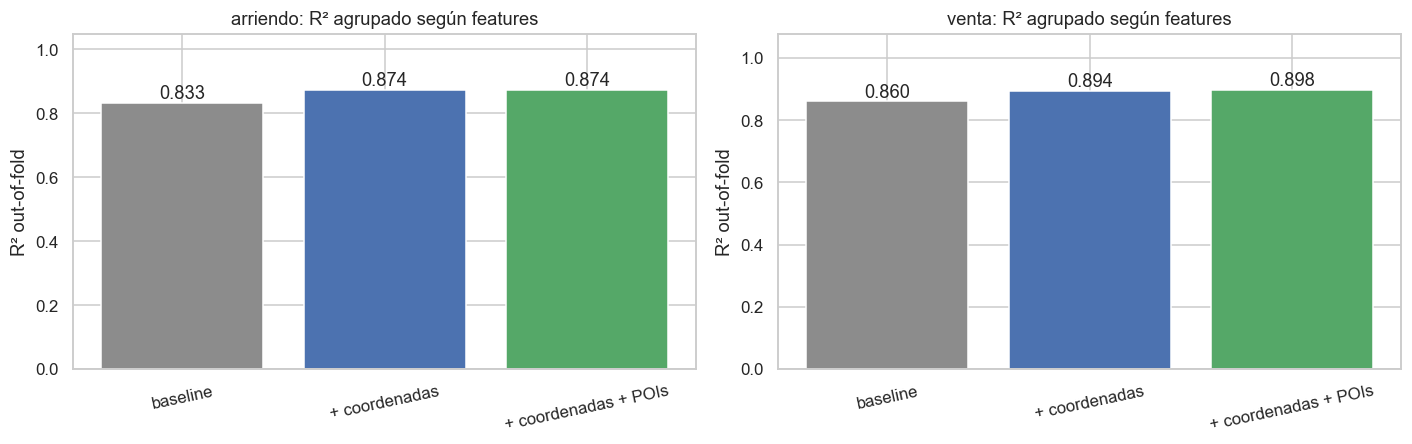

In [23]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2))
for eje, nombre in zip(ejes, OPERACIONES):
    sub = tabla_lift[tabla_lift["etiqueta"].str.startswith(nombre)]
    etiquetas = sub["etiqueta"].str.split(": ").str[1]
    barras = eje.bar(etiquetas, sub["R2"], color=["#8C8C8C", "#4C72B0", "#55A868"])
    eje.bar_label(barras, fmt="%.3f")
    eje.set_title(f"{nombre}: R² agrupado según features")
    eje.set_ylabel("R² out-of-fold")
    eje.set_ylim(0, max(sub["R2"]) * 1.2)
    eje.tick_params(axis="x", rotation=12)
plt.tight_layout()
plt.show()

## 12. Estrato socioeconómico: evaluación (no implementado acá)

El estrato es, para Colombia, probablemente **la variable de ubicación más predictiva que existe**:
es un número del 1 al 6 asignado oficialmente por manzana, correlaciona fortísimo con el valor del
suelo, y resuelve exactamente el problema del §6 — colapsa miles de sectores en **6 niveles ordinales
densos**.

Por qué no está en este prototipo:

**No hay una API nacional.** El estrato lo administra cada municipio. Lo que existe son datasets
abiertos, por ciudad, en formato geoespacial (shapefile/GeoJSON de manzanas con su estrato):

| Ciudad | Fuente | Formato |
|---|---|---|
| Bogotá | `datosabiertos.bogota.gov.co` — manzana estratificada | SHP / GeoJSON |
| Medellín | GeoMedellín — estratificación por manzana | SHP / WFS |
| Cali | Datos Abiertos Cali | SHP |
| Barranquilla | POT / catastro distrital | SHP |
| DANE | Marco geoestadístico nacional (manzanas) | SHP |

**Qué cuesta**: descarga manual por ciudad + join espacial punto-en-polígono. Eso sí necesita
`geopandas`/`shapely` de verdad — no hay atajo por API.

**Advertencia técnica importante**: el join sería contra el **centroide del barrio**, no contra la
dirección del inmueble. Un barrio grande puede cruzar estratos 3, 4 y 5. El estrato así obtenido es
**el modal del barrio**, con error de asignación en las fronteras. Sigue siendo muy útil, pero hay
que nombrarlo por lo que es.

**Recomendación**: implementarlo, empezando por Bogotá y Medellín (52 % de los anuncios). Es el
enriquecimiento con mejor relación señal/esfuerzo de todos los evaluados — mejor que los POIs, porque
el estrato ya integra en un solo número lo que los POIs miden de forma indirecta y ruidosa.

## 13. Conclusiones

### Sobre la data actual

1. **Hay 5 features, y valen como ~2.** `area_m2` domina (Spearman 0,875 con el precio). `banos` y
   `habitaciones` correlacionan 0,84 y 0,82 **con el área**: son proxies del tamaño, no información
   independiente. Al descontar el área, su correlación parcial con el precio se desploma.
2. **La ubicación es la señal grande que falta.** `ciudad + sector` explica R² 0,64 in-sample sobre
   `log(precio/m²)` — el triple que la ciudad sola. Pero out-of-fold cae a 0,32. Con 3.948 sectores
   de una sola fila, la categórica memoriza en vez de aprender. El techo honesto de hoy es
   `ciudad + tipo`: 0,42 out-of-fold con solo 368 niveles.
3. **Tres features están censuradas.** `habitaciones`/`banos` topan en 5, `parqueaderos` en 4. Las
   banderas `*_es_tope` tienen que entrar al modelo.
4. **Hay 8–12 % de near-duplicados.** Sin `GroupKFold` la métrica se infla y el informe miente.
5. **Es un snapshot.** `fecha_extraccion` tiene un solo valor: el modelo predice precio **de lista**,
   a fecha fija. No hay serie temporal, no hay precio de cierre, no hay estacionalidad.

### Sobre enriquecer: sí — y el prototipo lo midió

**El enriquecimiento paga, pero no por donde uno esperaría.** Sobre el mismo subconjunto de filas y
con el mismo modelo:

| escenario | arriendo R² | venta R² | MAPE arriendo |
|---|---|---|---|
| baseline (features actuales) | 0,833 | 0,860 | 25,4 % |
| **+ coordenadas del barrio** | **0,874** | **0,894** | **21,8 %** |
| + coordenadas + 7 columnas de POIs | 0,874 | 0,898 | 21,8 % |

**Las coordenadas son el 90 % del beneficio.** Dos columnas (`lat`, `lon`) valen +0,041 de R² y
bajan el error relativo casi 4 puntos. **Los siete conteos de POIs juntos agregan +0,000 y +0,004** —
son en gran medida una función de la posición, y el modelo ya tenía la posición.

Prioridad revisada, con la evidencia sobre la mesa:

| Prioridad | Qué | Esfuerzo | Evidencia |
|---|---|---|---|
| **1** | **Coordenadas del barrio** (gazetteer OSM) | Bajo | **Medido: +0,041 / +0,034 de R².** Ya prototipado y cacheado. |
| **2** | **Estrato** (Bogotá + Medellín primero) | Medio | No medido acá, pero es la única variable que ataca el 55 % de filas **sin match**, donde las coordenadas no llegan. |
| **3** | Ampliar cobertura del gazetteer | Bajo | 55,4 % de las filas no matchearon. Subir cobertura vale más que agregar columnas nuevas. |
| **4** | Distancia al CBD, altura | Bajo | Derivables de las coordenadas, sin requests extra. |
| ⚠️ | **POIs por radio** | Bajo | **Medido: +0,000 / +0,004.** Redundantes con las coordenadas. Guardarlos por interpretabilidad, no por precisión. |
| ❌ | **Match fuzzy de nombres** | Bajo | **Medido: empeora arriendo** (0,877 → 0,874). Suma 0,7 % de cobertura y mete centroides falsos. |
| ❌ | `osmnx` / análisis de red vial | Alto | No se justifica: contar POIs en un radio no necesita grafos. |

**La lección de prioridad**: el cuello de botella no son más columnas, es la **cobertura**. Con
43,9 % de match exacto, más de la mitad de los anuncios se quedan sin geografía. Subir eso —con
estrato, con más fuentes de barrios, o normalizando nombres contra un catálogo oficial— rinde más que
cualquier feature nueva sobre las filas que ya matchean.

### Qué hacer con el pipeline

Esto no debería vivir en un notebook. La secuencia natural es una etapa nueva:

```
extract → transform → enrich → (modelo)
```

`src/enrich.py` con la misma forma que `src/transform.py`: entrada `data/processed/anuncios.parquet`,
salida `data/processed/anuncios_enriquecido.parquet` + un `enrich_resumen.json` reportando cobertura
por ciudad. El caché de `data/external/` se vuelve parte del estado del pipeline, y el servicio se
encadena en `docker-compose.yml` después de `transform`.

### Advertencias para quien entrene el modelo

- **Un modelo por operación.** Canon y precio de venta no comparten escala.
- **Target `log(precio)`**, métrica MAE en log (≈ error relativo).
- **Split agrupado** por la llave de near-duplicado. Siempre.
- **El transform sesgó la población**: sin inmuebles no residenciales y con las colas de precio
  recortadas por IQR. El modelo va a fallar justo en el segmento de lujo, porque casi no lo vio.
- Los POIs de OSM miden equipamiento **y** cuánto mapeó la comunidad esa zona. Sirven para predecir;
  no sostienen una afirmación causal.